<a href="https://colab.research.google.com/github/MInesGomes/DataScienceObesityLevels/blob/main/DSGroup2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Preprocessing and Exploratory Data Analysis (EDA)** (Ines)

1.1.   Handling missing values and inconsistencies ( Done) (It doesn’t make sense to find for duplicates because doesn’t have a person ID)

1.2.   Encoding categorical variables (Done)

1.3.  Feature scaling and transformation (Done)

1.4 Identifying outliers (half Done)

1.5 Exploring relationships between variables through visualizations

In [1]:
import pandas as pd
import numpy as np

# df = pd.read_csv('/content/ObesityDataSet_raw_and_data_sinthetic.csv')
github_url = 'https://raw.githubusercontent.com/MInesGomes/DataScienceObesityLevels/main/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(github_url)

print("\nDataset info:")
print(df.info())
print("\nFirst 5 rows of the dataset:")
display(df.head())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### 1.1. Handling missing values and inconsistencies

 The dataset contains 2111 entries and 17 columns.

 There are no missing values in any of the columns, as indicated by the 'Non-Null Count'.

 The columns include both numerical (e.g., Age, Height, Weight) and categorical (e.g., Gender, family_history_with_overweight, NObeyesdad) data types.

In [18]:
# Rename the column 'family_history_with_overweight' to 'FamHist' in df to simplify view
df = df.rename(columns={'family_history_with_overweight': 'FamHist'})

print("\nTesting Possible inconsistency: someone that drinks Frequently and is under 19")
PossInconsist=df.query("CALC=='Frequently' & Age < 19")
display(PossInconsist)

print("\nTesting Possible inconsistency: someone that drinks Sometimes and is under 17")
PossInconsist=df.query("CALC=='Sometimes' & Age < 17")
display(PossInconsist)

print("\nTesting Possible inconsistency: : someone that smoke and is under 19")
PossInconsist=df.query("SMOKE=='yes' & Age < 19")
display(PossInconsist)

# Show counts for categorical features
print("\nShow counts for categorical features:")
for column in df.select_dtypes(include='object').columns:
    print("\n",df[column].value_counts())

print("\n Describe numerical variables")
df.describe().T


Testing Possible inconsistency: someone that drinks Frequently and is under 19


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
125,Male,18.000000,1.750000,80.000000,yes,yes,2.000000,3.000000,Always,no,2.000000,no,0.000000,0.000000,Frequently,Public_Transportation,Overweight_Level_I
298,Male,18.000000,1.800000,80.000000,yes,yes,2.000000,3.000000,Frequently,no,1.000000,no,0.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
334,Female,18.000000,1.450000,53.000000,no,yes,2.000000,3.000000,Frequently,no,2.000000,yes,1.000000,2.000000,Frequently,Public_Transportation,Overweight_Level_I
417,Male,18.000000,1.770000,87.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.000000,no,1.000000,1.000000,Frequently,Public_Transportation,Overweight_Level_II
436,Female,18.000000,1.560000,55.000000,no,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Frequently,Automobile,Normal_Weight
754,Female,18.836315,1.751631,80.000000,yes,yes,2.000000,1.737620,Sometimes,no,2.207978,no,2.641072,0.707044,Frequently,Public_Transportation,Overweight_Level_I
801,Female,18.270434,1.737165,76.699774,yes,yes,2.838969,3.000000,Sometimes,no,2.425927,no,1.000000,1.453335,Frequently,Public_Transportation,Overweight_Level_I
818,Male,18.900253,1.750359,79.828725,yes,yes,2.000000,2.228113,Sometimes,no,2.045004,no,1.293665,0.961806,Frequently,Public_Transportation,Overweight_Level_I
889,Female,18.869151,1.756774,79.989789,yes,yes,2.000000,2.658639,Sometimes,no,2.781628,no,1.955992,1.409198,Frequently,Public_Transportation,Overweight_Level_I
969,Male,18.014333,1.751029,80.000000,yes,yes,2.000000,2.805436,Sometimes,no,2.122884,no,0.045651,0.017225,Frequently,Public_Transportation,Overweight_Level_I



Testing Possible inconsistency: someone that drinks Sometimes and is under 17


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
290,Male,16.000000,1.820000,71.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
302,Male,16.000000,1.840000,45.000000,yes,yes,3.000000,3.000000,Always,no,3.000000,no,3.000000,2.000000,Sometimes,Walking,Insufficient_Weight
303,Female,16.000000,1.570000,49.000000,no,yes,2.000000,4.000000,Always,no,2.000000,no,0.000000,1.000000,Sometimes,Public_Transportation,Normal_Weight
553,Male,16.306870,1.752755,50.000000,no,yes,2.310423,3.558637,Sometimes,no,1.787843,no,1.926592,0.828549,Sometimes,Public_Transportation,Insufficient_Weight
554,Male,16.198153,1.691007,52.629374,no,yes,2.000000,2.000986,Sometimes,no,2.673835,no,0.992950,0.474836,Sometimes,Public_Transportation,Insufficient_Weight
563,Female,16.270434,1.818268,47.124717,no,yes,3.000000,3.286431,Sometimes,no,2.148146,no,2.458237,1.273333,Sometimes,Public_Transportation,Insufficient_Weight
624,Male,16.496978,1.691206,50.000000,no,yes,2.000000,1.630846,Sometimes,no,2.975528,no,0.548991,0.369134,Sometimes,Public_Transportation,Insufficient_Weight
627,Female,16.611837,1.830068,43.534531,no,yes,2.945967,3.000000,Sometimes,no,2.953192,no,2.830911,1.466667,Sometimes,Public_Transportation,Insufficient_Weight
689,Female,16.834813,1.744020,50.000000,no,yes,2.190050,3.420618,Sometimes,no,1.356405,no,1.351996,0.984680,Sometimes,Public_Transportation,Insufficient_Weight
698,Female,16.613108,1.777929,44.762023,no,yes,2.911877,3.098399,Sometimes,no,2.196405,no,2.328147,1.550110,Sometimes,Public_Transportation,Insufficient_Weight



Testing Possible inconsistency: : someone that smoke and is under 19


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
294,Male,18.0,1.86,110.0,yes,yes,2.0,1.0,Sometimes,yes,2.0,no,1.0,2.0,Sometimes,Public_Transportation,Obesity_Type_I



Show counts for categorical features:

 Gender
Male      1068
Female    1043
Name: count, dtype: int64

 FamHist
yes    1726
no      385
Name: count, dtype: int64

 FAVC
yes    1866
no      245
Name: count, dtype: int64

 CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

 SMOKE
no     2067
yes      44
Name: count, dtype: int64

 SCC
no     2015
yes      96
Name: count, dtype: int64

 CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

 MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

 Describe numerical variables


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


The inspection of categorical columns (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad) has revealed no obvious inconsistencies or data entry errors in their unique values.

All values appear to be valid categories for their respective columns. The CALC column has one entry for 'Always', which might be an outlier.

We'll Replace 'Always' with 'Frequently' in  the CALC feature which might be an outlier.

In [3]:
# Initialize df_CALC_out to store the changed value for the possible outlier
df_CALC_out = df.copy()
df_CALC_out['CALC'] = df['CALC'].replace('Always', 'Frequently')

print("Value counts for 'CALC' after replacement:")
print(df_CALC_out['CALC'].value_counts())


Value counts for 'CALC' after replacement:
CALC
Sometimes     1401
no             639
Frequently      71
Name: count, dtype: int64


### 1.2 Encoding Categorical Variables

To encode the categorical variables we'll:

1.  Convert binary columns to 0s and 1s.
2.  Use one-hot encoding for CAEC, CALC, and MTRANS.
3.  For the target variable NObeyesdad, we'll apply ordinal encoding to maintain the order of obesity levels.



In [4]:
# Initialize df_bin as a copy of df_CALC_out to store binary encoded columns
df_bin = df_CALC_out.copy()

# Encoding binary categorical columns
df_bin['Gender'] = df_CALC_out['Gender'].map({'Female': 0, 'Male': 1})
df_bin['FamHist'] = df_CALC_out['FamHist'].map({'no': 0, 'yes': 1})
df_bin['FAVC'] = df_CALC_out['FAVC'].map({'no': 0, 'yes': 1})
df_bin['SMOKE'] = df_CALC_out['SMOKE'].map({'no': 0, 'yes': 1})
df_bin['SCC'] = df_CALC_out['SCC'].map({'no': 0, 'yes': 1})

print("DataFrame after encoding binary columns:")
display(df_bin.head())

DataFrame after encoding binary columns:


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
# One-hot encoding for multi-category nominal features
nominal_cols = ['CAEC', 'CALC', 'MTRANS']
df_hot = pd.get_dummies(df_bin, columns=nominal_cols, drop_first=True, dtype=int)

print("\nDataFrame after one-hot encoding:")
display(df_hot.head())



DataFrame after one-hot encoding:


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,SMOKE,CH2O,...,NObeyesdad,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,...,Normal_Weight,0,1,0,0,1,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,...,Normal_Weight,0,1,0,1,0,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,...,Normal_Weight,0,1,0,0,0,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,...,Overweight_Level_I,0,1,0,0,0,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,...,Overweight_Level_II,0,1,0,1,0,0,0,1,0


In [6]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order of the obesity levels
obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

df_clean = df_hot.copy()
# Initialize the OrdinalEncoder with the specified categories
encoder = OrdinalEncoder(categories=[obesity_order])

# Apply ordinal encoding to the 'NObeyesdad' column
df_clean['TargetObesityL'] = encoder.fit_transform(df_clean[['NObeyesdad']])

# Drop the original 'NObeyesdad' column if desired, or keep both
df_clean = df_clean.drop(columns=['NObeyesdad'])

print("\nDataFrame after ordinal encoding 'NObeyesdad':")
display(df_clean.head())
print("\nUnique encoded values for 'TargetObesityL':")
print(df_clean['TargetObesityL'].value_counts())



DataFrame after ordinal encoding 'NObeyesdad':


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,SMOKE,CH2O,...,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,TargetObesityL
0,0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,...,0,1,0,0,1,0,0,1,0,1.0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,...,0,1,0,1,0,0,0,1,0,1.0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,...,0,1,0,0,0,0,0,1,0,1.0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,...,0,1,0,0,0,0,0,0,1,2.0
4,1,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,...,0,1,0,1,0,0,0,1,0,3.0



Unique encoded values for 'TargetObesityL':
TargetObesityL
4.0    351
6.0    324
5.0    297
2.0    290
3.0    290
1.0    287
0.0    272
Name: count, dtype: int64


### Feature Scaling and Transformation

In [7]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_clean.copy()

# Identify numerical columns for scaling (excluding the encoded target variable)
numerical_cols = df_scaled.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('TargetObesityL') # Exclude the target variable from scaling

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("\nDataFrame after feature scaling:")
display(df_scaled.head())



DataFrame after feature scaling:


,Gender,Age,Height,Weight,FamHist,FAVC,FCVC,NCP,SMOKE,CH2O,...,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,TargetObesityL
0,-1.011914,-0.522124,-0.875589,-0.862558,0.472291,-2.759769,-0.785019,0.404153,-0.145900,-0.013073,...,-0.359835,0.442757,-0.157344,-1.404720,1.517761,-0.05768,-0.072375,0.579721,-0.165078,1.0
1,-1.011914,-0.522124,-1.947599,-1.168077,0.472291,-2.759769,1.088342,0.404153,6.853997,1.618759,...,-0.359835,0.442757,-0.157344,0.711885,-0.658865,-0.05768,-0.072375,0.579721,-0.165078,1.0
2,0.988227,-0.206889,1.054029,-0.366090,0.472291,-2.759769,-0.785019,0.404153,-0.145900,-0.013073,...,-0.359835,0.442757,-0.157344,-1.404720,-0.658865,-0.05768,-0.072375,0.579721,-0.165078,1.0
3,0.988227,0.423582,1.054029,0.015808,-2.117337,-2.759769,1.088342,0.404153,-0.145900,-0.013073,...,-0.359835,0.442757,-0.157344,-1.404720,-0.658865,-0.05768,-0.072375,-1.724969,6.057758,2.0
4,0.988227,-0.364507,0.839627,0.122740,-2.117337,-2.759769,-0.785019,-2.167023,-0.145900,-0.013073,...,-0.359835,0.442757,-0.157344,0.711885,-0.658865,-0.05768,-0.072375,0.579721,-0.165078,3.0


# Visualisation

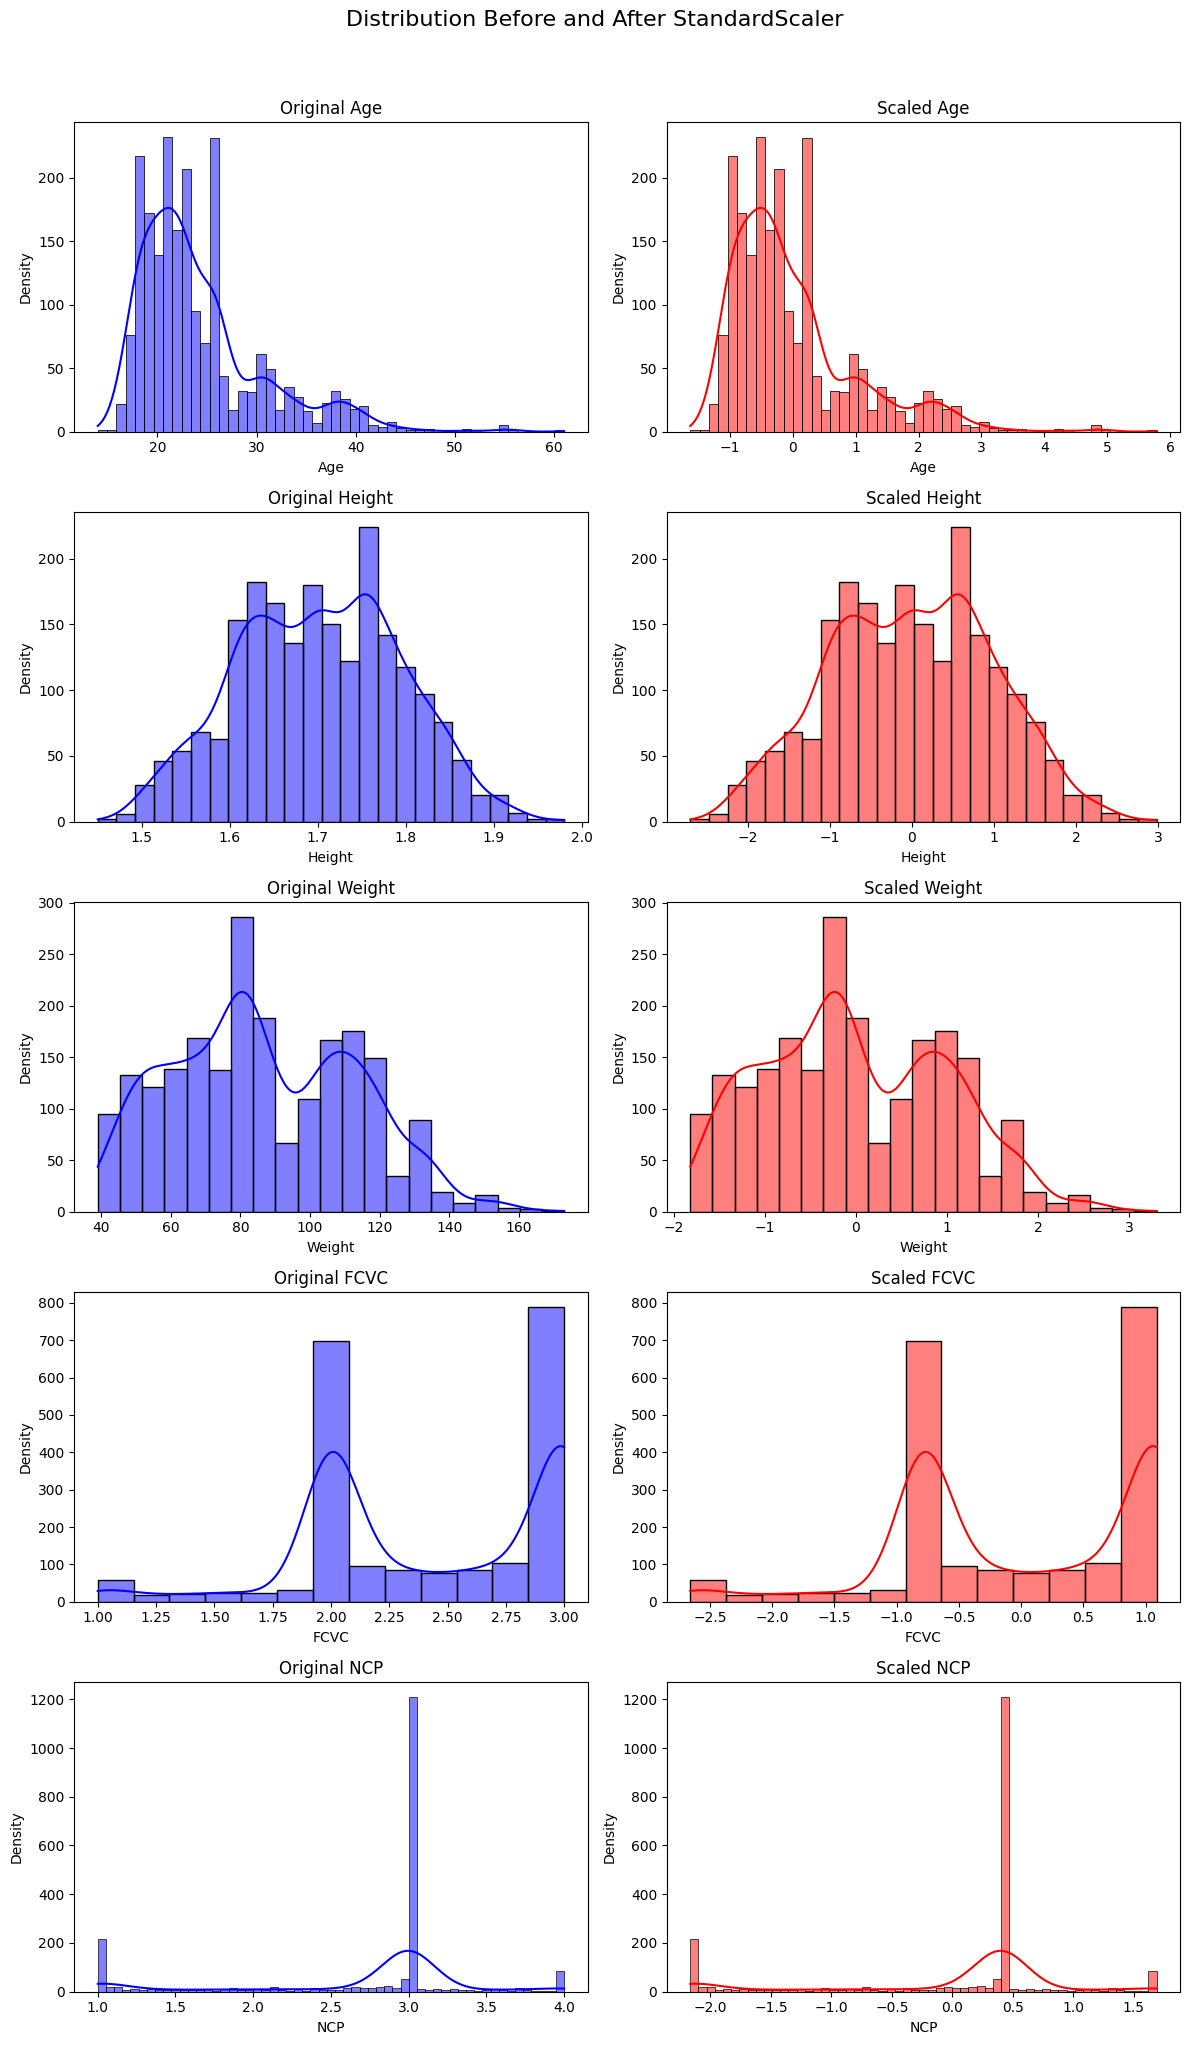

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few numerical columns for visualization
columns_to_plot = ['Age', 'Height', 'Weight', 'FCVC', 'NCP']

# Create subplots for comparison
fig, axes = plt.subplots(len(columns_to_plot), 2, figsize=(12, 4 * len(columns_to_plot)))
fig.suptitle('Distribution Before and After StandardScaler', fontsize=16, y=1.02)

for i, col in enumerate(columns_to_plot):
    # Plot original distribution
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Original {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Density')

    # Plot scaled distribution
    sns.histplot(df_scaled[col], kde=True, ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'Scaled {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

### 1.4 Identifying Outliers (using IQR method)

We will identify outliers in the numerical columns using the Interquartile Range (IQR) method.
This involves calculating the first quartile (Q1), third quartile (Q3), and the IQR for each numerical feature, and then defining upper and lower bounds to detect any values falling outside these ranges.

In [9]:
import numpy as np

# Identify numerical columns for outlier detection (excluding one-hot encoded and target variable)
# We'll use the 'numerical_cols' list from the previous scaling step, as it contains only original numerical features

print("Identifying outliers using the IQR method:")

outlier_summary = {} # Dictionary to store outlier counts

for col in numerical_cols:
    Q1 = df_scaled[col].quantile(0.25)
    Q3 = df_scaled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_scaled[(df_scaled[col] < lower_bound) | (df_scaled[col] > upper_bound)]

    # Store the count of outliers
    outlier_summary[col] = len(outliers)

    if not outliers.empty:
        print(f"\nColumn '{col}': {len(outliers)} outliers detected (min: {outliers[col].min()}, max: {outliers[col].max()})")
        # if len(outliers) < 3:
        display(outliers[[col]].head())

print("\nSummary of Outliers Detected:")
for col, count in outlier_summary.items():
   if count > 0: print(f"'{col}': {count} outliers")


Identifying outliers using the IQR method:

Column 'Age': 168 outliers detected (min: 1.7042888644462164, max: 5.78258370912611)


,Age
13,2.630230
21,4.364024
33,2.314994
92,4.836877
104,2.157377



Column 'Height': 1 outliers detected (min: 2.983646422857264, max: 2.983646422857264)


,Height
349,2.983646



Column 'Weight': 1 outliers detected (min: 3.3001355390339633, max: 3.3001355390339633)


...


Column 'MTRANS_Motorbike': 11 outliers detected (min: 13.816985594155149, max: 13.816985594155149)


,MTRANS_Motorbike
6,13.816986
30,13.816986
137,13.816986
273,13.816986
365,13.816986



Column 'MTRANS_Walking': 56 outliers detected (min: 6.0577577181188555, max: 6.0577577181188555)


,MTRANS_Walking
3,6.057758
20,6.057758
26,6.057758
29,6.057758
32,6.057758



Summary of Outliers Detected:
'Age': 168 outliers
'Height': 1 outliers
'Weight': 1 outliers
'FamHist': 385 outliers
'FAVC': 245 outliers
'NCP': 579 outliers
'SMOKE': 44 outliers
'SCC': 96 outliers
'CAEC_Frequently': 242 outliers
'CAEC_Sometimes': 346 outliers
'CAEC_no': 51 outliers
'MTRANS_Bike': 7 outliers
'MTRANS_Motorbike': 11 outliers
'MTRANS_Walking': 56 outliers


# **2. Additional Insights**

# 2.1  Do physical activity levels significantly influence obesity classification?


FAF  **Cont** - Frequency of physical activity

---
# 2.2  Are eating habits stronger predictors of obesity than demographic factors?


FAVC **Bin** -Indicates whether the individual frequently consumes high-calorie food

FCVC -**Int** -Frequency of vegetable consumption during meals

NCP - **Cont** Number of main meals consumed daily

CAEC **Cat** -Frequency of food consumption
between meals

SMOKE  **Bin** - Indicates whether the individual smokes

CH2O - **Cont** - Amount of water consumed daily

SCC **Bin** - Indicates whether the individual monitors daily calorie intake


CALC **Cat** - Frequency of alcohol consumption

---
2.3  Is there a relationship between technology usage (screen time) and obesity levels?


TUE **Int** - Time spent using technological devices (e.g., smartphone, computer, television, videogames)

---
2.4  Do transportation habits correlate with healthier lifestyles?

MTRANS **Cat** - Primary mode of transportation used

---
2.5  Can obesity patterns vary across age groups or genders?

Gender  **Cat** Gender of the individual

---
Age

Height




In [10]:
# MTRANS will be useful to the question: Do transportation habits correlate with healthier lifestyles?

In [11]:
#code here

**3. Predictive Modeling**

* Logistic Regression
* Decision Trees
* Random Forest
* Support Vector Machines
* K-Nearest Neighbors
* Gradient Boosting methods

**Students should:**

* Select relevant features
* Train and evaluate multiple models
* Compare model performance
* Apply hyperparameter tuning
* Interpreting the most important predictors


**Performance should be evaluated using appropriate metrics such as:**
* Accuracy
* Precision
* Recall

In [12]:
#code here

**NObeyesdad** represents the obesity classification of each individual.

The categories include:

* Insufficient Weight
* Normal Weight
* Overweight Level I
* Overweight Level II
* Obesity Type I
* Obesity Type II
* Obesity Type III

You will use this variable as the target variable for predictive modeling.